# Imports

In [37]:
import numpy as np
import pandas as pd
import scipy as sp
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import yellowbrick

sns.set_style('dark')

RANDOM_STATE = 42

In [2]:
data = pd.read_csv('../case_data_science_credit.csv', sep=';')
data = data.iloc[0:1000, :]
print(data.head())

   client_id pf_ou_pj grade sub_grade  qtd_restritivos  \
0      75521       PF     B        C4                0   
1      28124       PF     C        D3                0   
2       8420       PF     F        D4                0   
3      22553       PF     C        C3                0   
4      62952       PF     C        D4                1   

  verificacao_fonte_de_renda  razao_credito_tomado_vs_renda_informada  \
0               Not Verified                                16.284758   
1            Source Verified                                15.412409   
2            Source Verified                                28.137619   
3            Source Verified                                18.043730   
4            Source Verified                                17.209886   

   patrimonio_total  qtd_atrasos_ultimos_2a  \
0      176346.62670                       1   
1       39833.92100                       0   
2       91506.69105                       0   
3      108286.57590     

# Capítulo 2

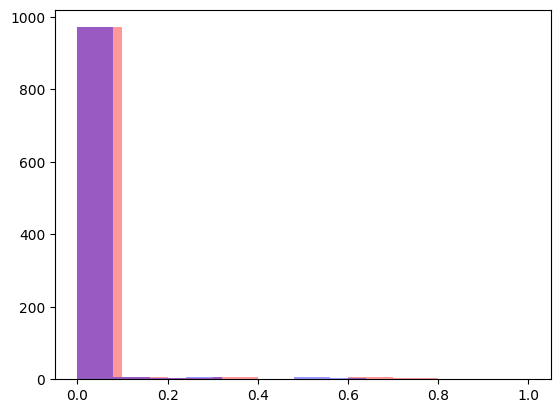

In [ ]:
# Página 75
# clip hiperparametro
# Set to True to clip transformed values of held-out data to provided feature range.
# O clip serve para efetuar o corte/truncamento ou não dos valores que ficam fora do intervalo estabelecido pelo feature_range
scaler = sk.preprocessing.MinMaxScaler()
scaler_clip = sk.preprocessing.MinMaxScaler(feature_range=(0, 0.8), clip=True)

vals = scaler.fit_transform(data[['razao_credito_tomado_vs_renda_informada', 'valor_total_recuperacoes_ultimos_2a']])
vals_clip = scaler_clip.fit_transform(data[['razao_credito_tomado_vs_renda_informada', 'valor_total_recuperacoes_ultimos_2a']])

plt.hist(pd.DataFrame(vals, columns=['A', 'B'])['B'], color='r', alpha=.4)
plt.hist(pd.DataFrame(vals_clip, columns=['A', 'B'])['B'], color='b', alpha=.4)
plt.show()

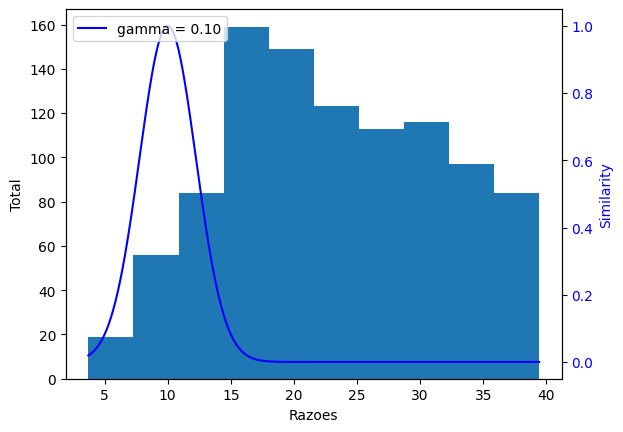

In [ ]:
# Página 78
# Gaussian RBF pra calculo de similaridade entre uma variavel e um valor especifico
# Variavel deve ser multimodal
# é possível criar uma feature com essa similaridade e verificar o decaimento dos valores ao redor do pico desejado
razoes = np.linspace(data['razao_credito_tomado_vs_renda_informada'].min(), data['razao_credito_tomado_vs_renda_informada'].max(), 1000).reshape(-1, 1)
similarity = sk.metrics.pairwise.rbf_kernel(razoes, [[10]], gamma=0.1)

fig, ax1 = plt.subplots()
ax1.set_xlabel('Razoes')
ax1.set_ylabel("Total")
ax1.hist(data['razao_credito_tomado_vs_renda_informada'])

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(razoes, similarity, color=color, label="gamma = 0.10")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Similarity", color=color)

plt.legend(loc="upper left")
plt.show()

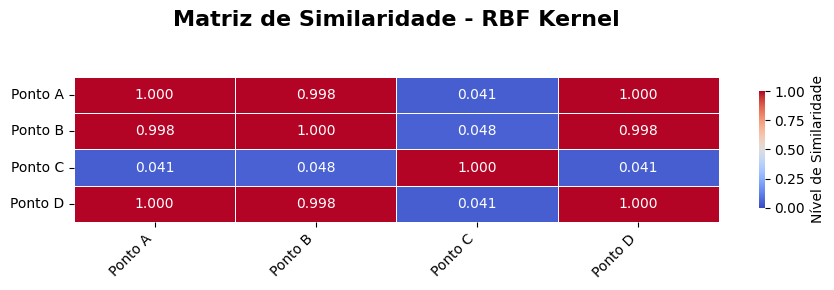

In [ ]:
# O kernel rbf tambem pode ser utilizado para calculo de similaridade entre amostras
# Criando dados
amostras = np.array([
    [1.0, 2.0],    # Ponto A
    [1.1, 2.1],    # Ponto B (muito próximo de A)
    [5.0, 6.0],    # Ponto C (distante)
    [1.0, 2.0]     # Ponto D (igual ao A)
])

# Calculando matriz de similaridade
gamma = 0.1  # Parâmetro de escala
matriz_similaridade = sk.metrics.pairwise.rbf_kernel(amostras, gamma=gamma)

# print("Matriz de Similaridade RBF:")
# print(matriz_similaridade)

# Configurações para melhor visualização
plt.style.use('default')
sns.set_palette("viridis")

# Rótulos para identificar os pontos no heatmap
rotulos = ['Ponto A', 'Ponto B', 'Ponto C', 'Ponto D']

# 4. Heatmap com mais customização
plt.figure(figsize=(9, 3))
heatmap = sns.heatmap(matriz_similaridade, 
                      annot=True, 
                      fmt='.3f', 
                      cmap='coolwarm',
                      vmin=0, 
                      vmax=1,
                      linewidths=0.5,
                      linecolor='white',
                      cbar_kws={'label': 'Nível de Similaridade', 
                               'shrink': 0.8},
                      xticklabels=rotulos,
                      yticklabels=rotulos,
                      annot_kws={'size': 10})

# Melhorar a aparência
plt.title('Matriz de Similaridade - RBF Kernel\n', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
heatmap.set_facecolor('#f0f0f0')  # Cor de fundo

plt.tight_layout()
plt.show()

In [66]:
# Página 94
# Ainda experimentais no scikitlearn
# HalvingRandomSearchCV e HalvingGridSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, HalvingGridSearchCV

"""
Scikit-Learn also has HalvingRandomSearchCV and HalvingGridSearchCV hyperparameter search classes. Their goal is to use the computational resources more efficiently,
either to train faster or to explore a larger hyperparameter space. Here’s how they work: in the first round, many hyperparameter combinations (called “candidates”) are
generated using either the grid approach or the random approach. These candidates are then used to train models that are evaluated using cross-validation, as usual.
However, training uses limited resources, which speeds up this first round considerably. By default, “limited resources” means that the models are trained on a small
part of the training set. However, other limitations are possible, such as reducing the number of training iterations if the model has a hyperparameter to set it. Once
every candidate has been evaluated, only the best ones go on to the second round, where they are allowed more resources to compete. After several rounds, the final
candidates are evaluated using full resources. This may save you some time tuning hyperparameters.
"""

'\nScikit-Learn also has HalvingRandomSearchCV and HalvingGridSearchCV hyperparameter search classes. Their goal is to use the computational resources more efficiently,\neither to train faster or to explore a larger hyperparameter space. Here’s how they work: in the first round, many hyperparameter combinations (called “candidates”) are\ngenerated using either the grid approach or the random approach. These candidates are then used to train models that are evaluated using cross-validation, as usual.\nHowever, training uses limited resources, which speeds up this first round considerably. By default, “limited resources” means that the models are trained on a small\npart of the training set. However, other limitations are possible, such as reducing the number of training iterations if the model has a hyperparameter to set it. Once\nevery candidate has been evaluated, only the best ones go on to the second round, where they are allowed more resources to compete. After several rounds, the 

# Capítulo 3

In [9]:
mnist = sk.datasets.fetch_openml('mnist_784', as_frame=False)
x_train, x_test, y_train, y_test = mnist.data[:60000], mnist.data[60000:], mnist.target[:60000], mnist.target[60000:]

In [ ]:
# Pagina 109
# verificar retorno da função cross_val_predict
y_train_5, y_test_5 = (y_train == '5'), (y_test == '5')
sgd = sk.linear_model.SGDClassifier()
sgd.fit(x_train, y_train_5)

# Retorna as previsões de cada fold para cada índice testado
y_pred = sk.model_selection.cross_val_predict(sgd, x_train, y_train_5, cv=3)

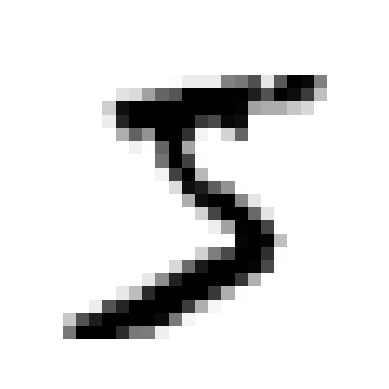

In [25]:
def plot_digit(img):
    img = img.reshape(28, 28)
    plt.imshow(img, cmap='binary')
    plt.axis('off')

plot_digit(x_train[0])

In [30]:
# Página 112
# A função de decisão pode é parecida com o threshold nos casos de probabilidade
y_scores = sgd.decision_function([x_train[0]])
y_scores

array([660.47932447])

In [53]:
# Página 113
# O cross_val_predict possui 3 métodos possíveis
# predict, predict_proba, decision_function
y_scores = sk.model_selection.cross_val_predict(sgd, x_train, y_train_5, cv=3, method='decision_function')
y_scores[:10]

array([  8959.85796186, -10868.64221291, -24001.15808352, -11978.12269041,
       -12578.9858138 ,  -5893.42382386, -12241.24336705, -10808.6408894 ,
        -6637.6470503 ,  -6669.09554806])

In [ ]:
# Página 113
# olhando os valores de threshold retonados
# os thresholds são pegos no score do cross_val_predict e por ele se calcula a precisão e recall
# scores são thresholds ou o valor retornado pela função de decisão
prec, rec, thres = sk.metrics.precision_recall_curve(y_train_5, y_scores)
thres

array([-128321.26674968, -123262.25371241, -121981.16428943, ...,
         28934.94249983,   29477.75730711,   37233.26976817],
      shape=(60000,))

In [67]:
import numpy as np
from sklearn.metrics import precision_recall_curve
y_true = np.array([0, 0, 1, 1, 0, 1, 1])
y_scores = np.array([0.1, 0.4, 0.2, 0.9, 0.35, 0.6, 0.25])
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
print(precision)
print(recall)
print(thresholds)

[0.57142857 0.66666667 0.6        0.5        0.66666667 1.
 1.         1.        ]
[1.   1.   0.75 0.5  0.5  0.5  0.25 0.  ]
[0.1  0.2  0.25 0.35 0.4  0.6  0.9 ]


In [72]:
# threshold 0.1
print(y_scores)
y_true = np.array([0, 0, 1, 1, 0, 1, 1])

threshold = 0.35
y_pred = (y_scores >= threshold).astype(int)
print(y_pred)

# Calcular matriz de confusão
TP = np.sum((y_pred == 1) & (y_true == 1))
FP = np.sum((y_pred == 1) & (y_true == 0))
FN = np.sum((y_pred == 0) & (y_true == 1))

print(TP, FP, FN)
# Calcular métricas
print(TP / (TP + FP) if (TP + FP) > 0 else 0)

[0.1  0.4  0.2  0.9  0.35 0.6  0.25]
[0 1 0 1 1 1 0]
2 2 2
0.5


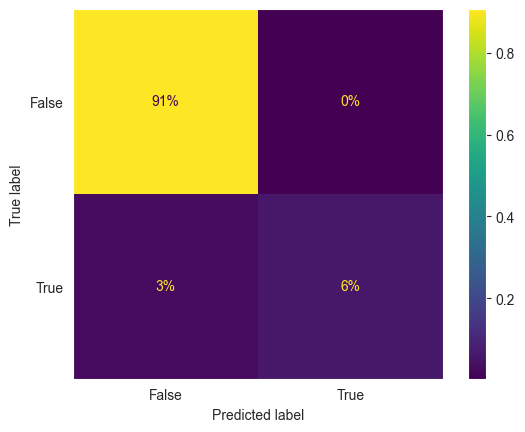

In [ ]:
# Página 122
# Confusion Matrix
# true -> row (foco em recall)
# pred -> column (foco em precisão)
# all -> acurácia total
from sklearn.metrics import ConfusionMatrixDisplay
y_train_pred = sgd.predict(x_train)
ConfusionMatrixDisplay.from_predictions(y_train_5, y_train_pred, normalize="all", values_format=".0%")

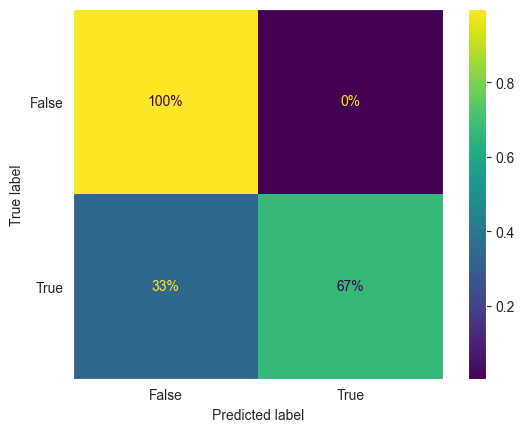

In [75]:
ConfusionMatrixDisplay.from_predictions(y_train_5, y_train_pred, normalize="true", values_format=".0%")

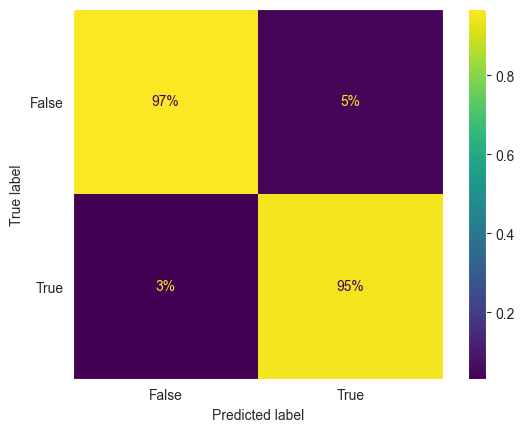

In [76]:
ConfusionMatrixDisplay.from_predictions(y_train_5, y_train_pred, normalize="pred", values_format=".0%")

# Capítulo 4

In [13]:
# Página 146

from sklearn.preprocessing import add_dummy_feature

# Criar dados
np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)
X_b = add_dummy_feature(X)

n_epochs = 50
t0, t1 = 5, 50 # Learning Rate Agendado -> usado para ir diminuindo durante o processo de treinamento do gradiente descendente estocástico

def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2, 1) # inicialização randomizada

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)  # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        print(f'EPOCH: {epoch} -- M: {m} -- ITERATION: {iteration} -- ETA: {eta}')
        theta = theta - eta * gradients

# Comparação com sklearn
from sklearn.linear_model import SGDRegressor

# Sobre o tol
# The stopping criterion. If it is not None, training will stop when (loss > best_loss - tol) for n_iter_no_change consecutive epochs.
sgd_reg = SGDRegressor(
    max_iter=1000, 
    tol=1e-5, 
    penalty=None, 
    eta0=0.01, 
    n_iter_no_change=100, 
    random_state=42)
sgd_reg.fit(X, y.ravel())

EPOCH: 0 -- M: 100 -- ITERATION: 0 -- ETA: 0.1
EPOCH: 0 -- M: 100 -- ITERATION: 1 -- ETA: 0.09803921568627451
EPOCH: 0 -- M: 100 -- ITERATION: 2 -- ETA: 0.09615384615384616
EPOCH: 0 -- M: 100 -- ITERATION: 3 -- ETA: 0.09433962264150944
EPOCH: 0 -- M: 100 -- ITERATION: 4 -- ETA: 0.09259259259259259
EPOCH: 0 -- M: 100 -- ITERATION: 5 -- ETA: 0.09090909090909091
EPOCH: 0 -- M: 100 -- ITERATION: 6 -- ETA: 0.08928571428571429
EPOCH: 0 -- M: 100 -- ITERATION: 7 -- ETA: 0.08771929824561403
EPOCH: 0 -- M: 100 -- ITERATION: 8 -- ETA: 0.08620689655172414
EPOCH: 0 -- M: 100 -- ITERATION: 9 -- ETA: 0.0847457627118644
EPOCH: 0 -- M: 100 -- ITERATION: 10 -- ETA: 0.08333333333333333
EPOCH: 0 -- M: 100 -- ITERATION: 11 -- ETA: 0.08196721311475409
EPOCH: 0 -- M: 100 -- ITERATION: 12 -- ETA: 0.08064516129032258
EPOCH: 0 -- M: 100 -- ITERATION: 13 -- ETA: 0.07936507936507936
EPOCH: 0 -- M: 100 -- ITERATION: 14 -- ETA: 0.078125
EPOCH: 0 -- M: 100 -- ITERATION: 15 -- ETA: 0.07692307692307693
EPOCH: 0 -- M:

SGDRegressor(n_iter_no_change=100, penalty=None, random_state=42, tol=1e-05)

In [14]:
# Theta final
theta

array([[4.1663779 ],
       [2.75360666]])

In [15]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

### Sobre penalidades L1 e L2

- L1: Lasso Regression -> ele força alguns coeficientes a ficarem exatamente zero
    - O modelo automaticamente seleciona variáveis
    - Alguns coeficientes viram zero - essas features saem do modelo
    - O modelo fica mais simples, mais "esparso"

- L2: Ridge Regression -> ele puxa o coeficiente para perto de zero, mas nunca deixa zerar
    - Coeficientes grandes são fortemente penalizados
    - O modelo fica suave, com pesos distribuídos

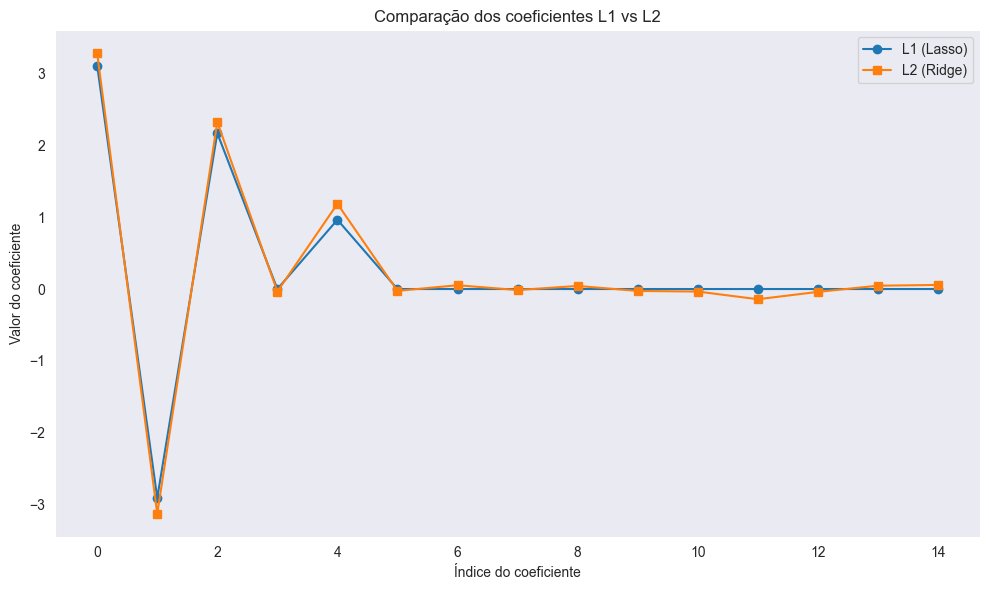

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler

# Generate synthetic data
np.random.seed(42)
n_samples, n_features = 80, 15
X = np.random.randn(n_samples, n_features)
true_coef = np.zeros(n_features)
true_coef[:5] = np.array([4, -3, 2.5, 0, 1.5])  # sparse signal
y = X.dot(true_coef) + np.random.randn(n_samples) * 0.5

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit L1 and L2 models
lasso = Lasso(alpha=0.2)
ridge = Ridge(alpha=0.2)
lasso.fit(X_scaled, y)
ridge.fit(X_scaled, y)

# Prepare plot of coefficients
plt.figure(figsize=(10, 6))
plt.plot(lasso.coef_, marker="o", label="L1 (Lasso)")
plt.plot(ridge.coef_, marker="s", label="L2 (Ridge)")
plt.xlabel("Índice do coeficiente")
plt.ylabel("Valor do coeficiente")
plt.title("Comparação dos coeficientes L1 vs L2")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
lasso.coef_

array([ 3.10597499, -2.90502982,  2.16820049,  0.        ,  0.96308969,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , -0.        , -0.        ,  0.        ,  0.        ])

In [24]:
ridge.coef_

array([ 3.27692824, -3.1250146 ,  2.32222682, -0.03457957,  1.18491968,
       -0.02550929,  0.05273182, -0.01435823,  0.04293845, -0.02667111,
       -0.03518281, -0.14175742, -0.03994881,  0.04615855,  0.05717985])

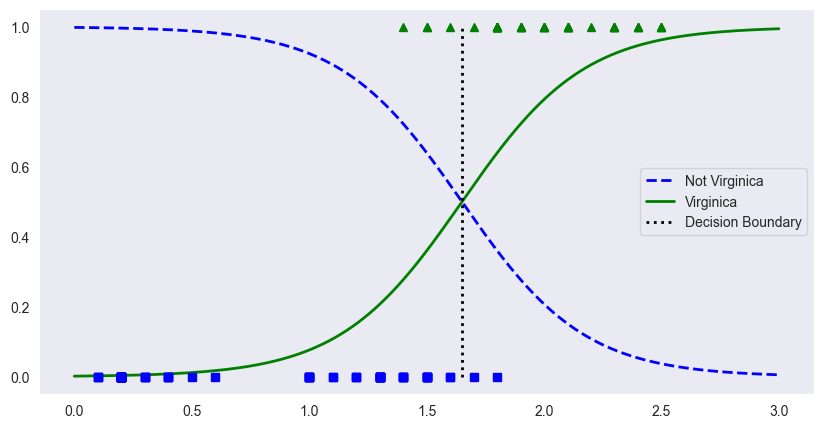

In [54]:
# Página 167 e 168

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

rd_st = 42

iris = load_iris(as_frame=True)
x = iris.data[['petal width (cm)']].values
y = iris.target_names[iris.target] == 'virginica'
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=rd_st)
mdl = LogisticRegression(random_state=rd_st)
mdl.fit(x_train, y_train)

nx = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = mdl.predict_proba(nx)

# Aqui se pega a fronteira de decisão pq foram gerados 
# 1000 números de forma q a partir de um determinado valor 
# todos passam a ser maior q 0.5
decision_boundary = nx[y_proba[:, 1] >= .5][0, 0]

plt.figure(figsize=(10, 5))
plt.plot(nx, y_proba[:, 0], 'b--', linewidth=2, label='Not Virginica')
plt.plot(nx, y_proba[:, 1], 'g-', linewidth=2, label='Virginica')
plt.plot([decision_boundary, decision_boundary], [0, 1], 'k:', linewidth=2, label='Decision Boundary')
plt.plot(x_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(x_train[y_train == 1], y_train[y_train == 1], "g^")
plt.legend()
plt.show()

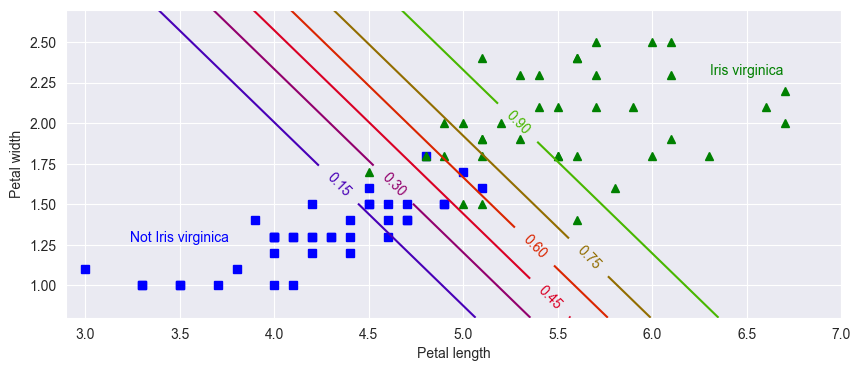

In [ ]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(C=2, random_state=42)
log_reg.fit(X_train, y_train)

# for the contour plot
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure
y_proba = log_reg.predict_proba(X_new)
zz = y_proba[:, 1].reshape(x0.shape)

# for the decision boundary
left_right = np.array([2.9, 7])
boundary = -((log_reg.coef_[0, 0] * left_right + log_reg.intercept_[0])
             / log_reg.coef_[0, 1])

plt.figure(figsize=(10, 4))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^")
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
plt.clabel(contour, inline=1)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.27, "Not Iris virginica", color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", color="g", ha="center")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.axis([2.9, 7, 0.8, 2.7])
plt.grid()
plt.show()

# Capítulo 9

In [24]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

x, y = make_blobs(n_samples=1000, centers=5, n_features=2, random_state=RANDOM_STATE)
data = pd.DataFrame(x, columns=['f1', 'f2'])
data['classe'] = y

<Axes: xlabel='f1', ylabel='f2'>

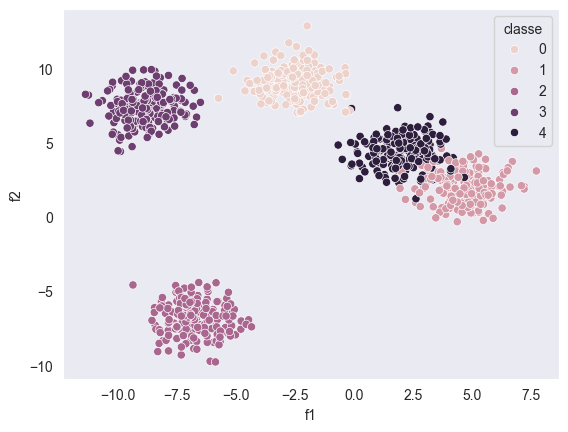

In [25]:
# Resultado do dataset criado
sns.scatterplot(data=data, x='f1', y='f2', hue='classe')

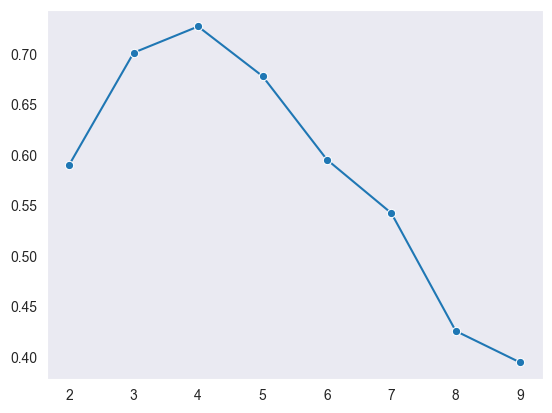

In [ ]:
# Página 268
# Para acelerar o treino do kmeans existe o algoritmo elkan

from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, algorithm='elkan').fit(x)
    scores.append(silhouette_score(x, km.predict(x)))

sns.lineplot(x=range(2, 10), y=scores, marker='o');

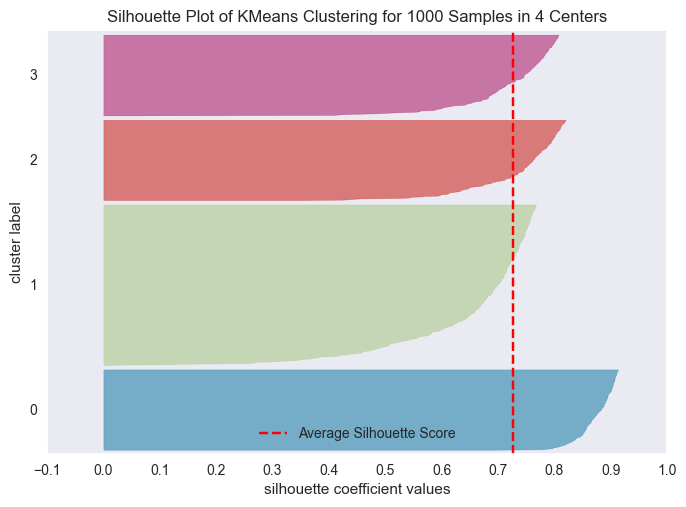

In [40]:
from yellowbrick.cluster import SilhouetteVisualizer

model = KMeans(4, random_state=RANDOM_STATE)
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
visualizer.fit(x)
visualizer.show();

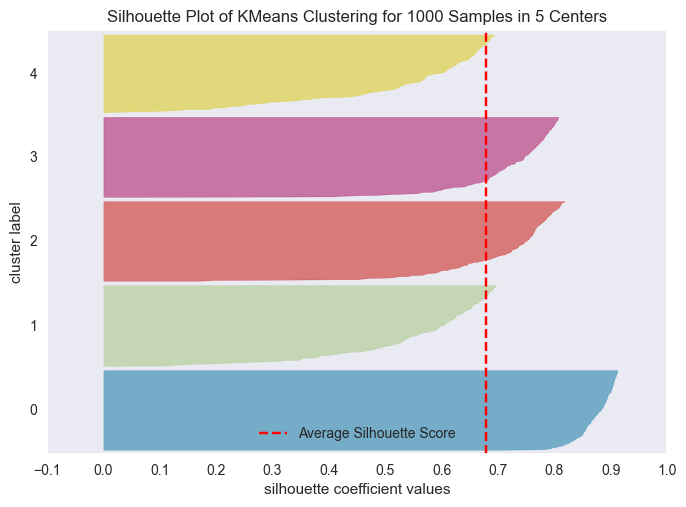

In [41]:
model = KMeans(5, random_state=RANDOM_STATE)
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
visualizer.fit(x)
visualizer.show();

In [74]:
# Página 276
from sklearn.datasets import load_digits
x_dig, y_dig = load_digits(return_X_y=True)
x_train, y_train = x_dig[:1400], y_dig[:1400]
x_test, y_test = x_dig[1400:], y_dig[1400:]

km = KMeans(n_clusters=50, random_state=RANDOM_STATE)
x_dig_dist = km.fit_transform(x_train)
rep_dig_idx = np.argmin(x_dig_dist, axis=0)
x_rep_dig = x_train[rep_dig_idx]

y_rep_dig = np.array([
     8, 0, 1, 3, 6, 7, 5, 4, 2, 8,
     2, 3, 9, 5, 3, 9, 1, 7, 9, 1,
     4, 6, 9, 7, 5, 2, 2, 1, 3, 3, 
     6, 0, 4, 9, 8, 1, 8, 4, 2, 4, 
     2, 3, 9, 7, 8, 9, 6, 5, 6, 4])

from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(x_rep_dig, y_rep_dig)
log_reg.score(x_test, y_test)

0.8312342569269522

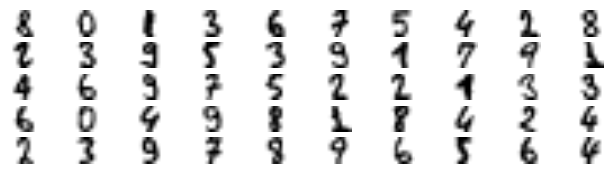

In [ ]:
k = 50
plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(x_rep_dig):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')
plt.show()

In [ ]:
# Página 277
# Propagação de label (label propagation)
y_train_propagate = np.empty(len(x_train), dtype=np.int64)
for i in range(k):
    y_train_propagate[km.labels_ == i] = y_rep_dig[i]

log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(x_train, y_train_propagate)
log_reg.score(x_test, y_test)

0.8664987405541562

In [92]:
# Página 279
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

x, y = make_moons(n_samples=1000, noise=0.05)
data = pd.DataFrame(x, columns=['f1', 'f2'])
data['classe'] = y

dbs = DBSCAN(eps=0.05, min_samples=5)
dbs.fit(x)

DBSCAN(eps=0.05)

<Axes: xlabel='f1', ylabel='f2'>

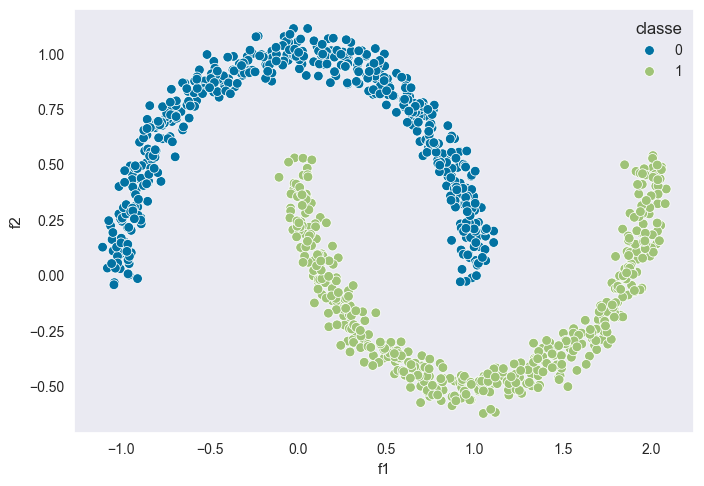

In [91]:
# Resultado do dataset criado
sns.scatterplot(data=data, x='f1', y='f2', hue='classe')

In [ ]:
# Labels definidos pelo algoritmo
# Se -1 é pq são considerados anomalias
# Os clusters que o algoritmo encontrou
print(dbs.labels_[0:100])

# Índices dos core_samples
print(dbs.core_sample_indices_[0:100])

# Componentes do core, são os próprios valores treinados
print(dbs.components_[0:100])

[ 0  1  1  0  0  0  2  3  3  4  3  2  2  5  2  0  6  2  6  6  2  2  3 -1
  6 -1  3  3  1  6  6  0  8  7  2  7  6  0  0  7  2  0  4  8  3  3  1  2
  1  8 -1  1 -1  8  0  3  2 -1  2  1  3  0  3  2  9  1  4  5  7  2  2  5
  6  7  3  7  1  3  9  8  0  2  3 -1  2  2  6  2  7 -1  6  8  2  3  1  3
  0  2  1  2]
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  16  17  18
  19  20  22  24  26  27  28  29  30  31  33  34  35  36  37  38  41  43
  45  46  47  48  49  51  55  56  58  59  60  62  63  64  65  66  67  68
  69  70  72  73  74  75  76  77  79  80  81  82  84  85  87  88  91  92
  93  94  95  96  97  98  99 100 101 102 103 105 107 108 109 111 112 113
 114 117 118 119 120 121 122 123 124 125]
[[ 1.94813463  0.23736669]
 [-0.70680094  0.71271743]
 [-0.56032441  0.88882325]
 [ 2.0401807   0.27195398]
 [ 2.0114417   0.21847951]
 [ 1.97427593  0.1159288 ]
 [ 1.06423567 -0.48853905]
 [ 1.67200123 -0.17856258]
 [ 1.49774545 -0.38639688]
 [-0.39226151  0.92062654]
 [ 1.69996407 -0.

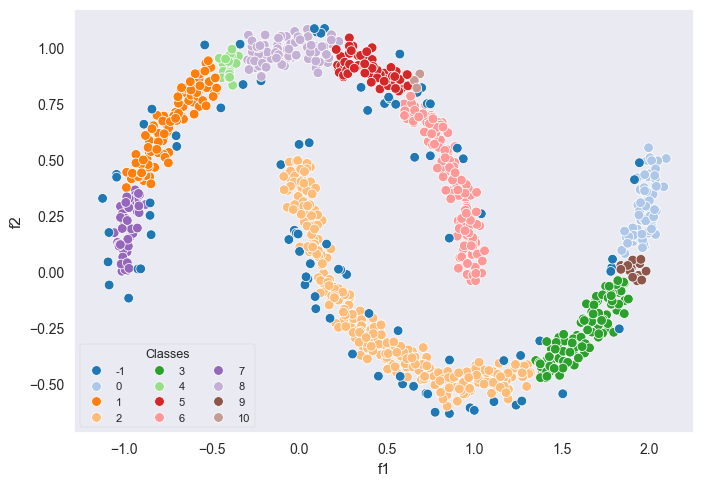

In [105]:
# Resultado do algoritmo
data = pd.DataFrame(x, columns=['f1', 'f2'])
data['classe'] = dbs.labels_
sns.scatterplot(data=data, x='f1', y='f2', hue='classe', palette='tab20')
plt.legend(
    title='Classes',
    title_fontsize=9,
    fontsize=8,
    loc='lower left',
    bbox_to_anchor=(0, 0),\
    ncol=3,
    frameon=True,
    framealpha=0.9,
    fancybox=True
)
plt.show()

In [108]:
# O DBSCAN não possui um método de predict então é possível usar um algoritmo pra poder treinar e retornar como fit
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbs.components_, dbs.labels_[dbs.core_sample_indices_])
print(knn.classes_)

x_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
print(knn.predict(x_new))
print(knn.predict_proba(x_new))

[ 0  1  2  3  4  5  6  7  8  9 10]
[7 2 6 0]
[[0.   0.06 0.06 0.   0.   0.   0.   0.88 0.   0.   0.  ]
 [0.   0.   0.98 0.   0.   0.   0.   0.   0.02 0.   0.  ]
 [0.   0.   0.2  0.   0.   0.   0.8  0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]]


In [109]:
# O algoritmo sempre retornará uma classe não importa o quão distante o elemento estiver
y_dist, y_pred_idx = knn.kneighbors(x_new, n_neighbors=1)
y_pred = dbs.labels_[dbs.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  2,  6, -1])

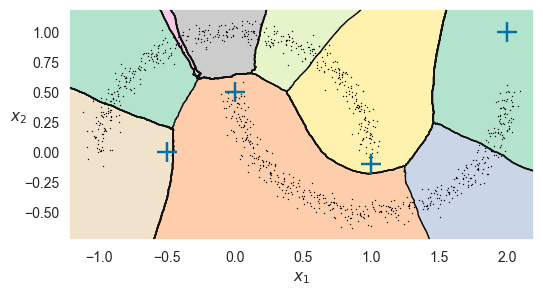

In [110]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)


def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, x, show_centroids=False)
plt.scatter(x_new[:, 0], x_new[:, 1], c="b", marker="+", s=200, zorder=10)
plt.show()